# Visualization Notebook — Hospital Tier Prediction
**Project:** Predicting the DOH Hospital Tier Available per LGU from Socioeconomic Features

This notebook produces all figures needed for the final report, in order of the storytelling arc:
1. The problem: unequal hospital access
2. The data: what LGUs look like across tiers
3. The PCA: reducing 9 features to 4 interpretable components
4. The model: what drives tier prediction
5. The finding: poverty suppresses tier
6. The actionable output: underserved LGUs

All figures saved to `outputs/figures/`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        130,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'legend.framealpha': 0.8,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

# ── Colour palette ────────────────────────────────────────────────────────────
TIER_COLORS  = ['#6c757d', '#2176ae', '#f4a261', '#2a9d8f']
TIER_LABELS  = ['Tier 0\n(No hospital)', 'Tier 1\n(Level 1)', 'Tier 2\n(Level 2)', 'Tier 3\n(Level 3)']
TIER_SHORT   = ['Tier 0', 'Tier 1', 'Tier 2', 'Tier 3']
BLUE         = '#2176ae'
ORANGE       = '#f4a261'
GREEN        = '#2a9d8f'
RED          = '#e63946'
GREY         = '#6c757d'
PC_COLORS    = ['#2176ae', '#e63946', '#2a9d8f', '#f4a261']
PC_NAMES     = ['PC1: Birth Demand', 'PC2: Poverty', 'PC3: City Size', 'PC4: Growth']

# ── Output directory ──────────────────────────────────────────────────────────
OUT_DIR = os.path.join('outputs', 'figures')
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(OUT_DIR, name)
    plt.savefig(path, bbox_inches='tight', dpi=130)
    plt.show()
    print(f"Saved: {name}")

print("Setup complete. Figures will be saved to:", OUT_DIR)


Setup complete. Figures will be saved to: outputs\figures


---
## 1. Data Loading and Feature Engineering

In [2]:
DB_PATH   = os.path.join('data', 'processed', 'hospital_data.db')
XLSX_PATH = os.path.join('data', 'clean', 'final_dataset_clean.xlsx')

if os.path.exists(DB_PATH):
    conn = sqlite3.connect(DB_PATH)
    df   = pd.read_sql('SELECT * FROM lgu_merged', conn)
    conn.close()
else:
    df = pd.read_excel(XLSX_PATH)
    if 'province_x' in df.columns:
        df = df.rename(columns={'province_x': 'province'})

FEATURES = [
    'population_2020', 'population_2024', 'pop_growth_rate_pct',
    'poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct',
    'births_residence_both', 'births_residence_male', 'births_residence_female',
]
for col in ['poverty_incidence_2018_pct','poverty_incidence_2021_pct','poverty_incidence_2023_pct',
            'births_residence_both','births_residence_male','births_residence_female']:
    reg = df.groupby('region')[col].transform('median')
    df[col] = df[col].fillna(reg).fillna(df[col].median())

df['tier'] = 0
df.loc[df['hospital_count_level1'] >= 1, 'tier'] = 1
df.loc[df['hospital_count_level2'] >= 1, 'tier'] = 2
df.loc[df['hospital_count_level3'] >= 1, 'tier'] = 3

_cols = list(dict.fromkeys(FEATURES + ['tier','city_municipality','region','poverty_incidence_2023_pct']))
model_df = df[_cols].dropna(subset=FEATURES).copy().reset_index(drop=True)

X_all = model_df[FEATURES]; y_all = model_df['tier']
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.25, random_state=42, stratify=y_all)

scaler      = StandardScaler()
X_tr_sc     = scaler.fit_transform(X_tr)
X_all_sc    = scaler.transform(X_all)

pca         = PCA(n_components=4, random_state=42)
X_tr_pca    = pca.fit_transform(X_tr_sc)
X_all_pca   = pca.transform(X_all_sc)

gbm = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=0)
gbm.fit(X_tr_pca, y_tr)

proba_full              = gbm.predict_proba(X_all_pca)
model_df['pred_tier']   = gbm.predict(X_all_pca)
model_df['tier_gap']    = model_df['pred_tier'] - model_df['tier']
model_df['expected_tier'] = (proba_full * np.array([0,1,2,3])).sum(axis=1)

for i in range(4):
    model_df[f'prob_tier{i}'] = proba_full[:, i]

underserved = model_df[model_df['tier_gap'] > 0].sort_values('expected_tier', ascending=False)
pov_median  = model_df['poverty_incidence_2023_pct'].median()
eq_prio     = underserved[underserved['poverty_incidence_2023_pct'] >  pov_median]
sup_prio    = underserved[underserved['poverty_incidence_2023_pct'] <= pov_median]

print(f"Dataset: {len(model_df)} LGUs")
print(f"Tiers: {model_df['tier'].value_counts().sort_index().to_dict()}")
print(f"Underserved: {len(underserved)} LGUs")
print(f"  Equity priority (high poverty): {len(eq_prio)}")
print(f"  Supply priority (lower poverty): {len(sup_prio)}")


Dataset: 1629 LGUs
Tiers: {0: 1339, 1: 196, 2: 73, 3: 21}
Underserved: 21 LGUs
  Equity priority (high poverty): 9
  Supply priority (lower poverty): 12


---
## Figure 1 — The Problem: Unequal Hospital Access

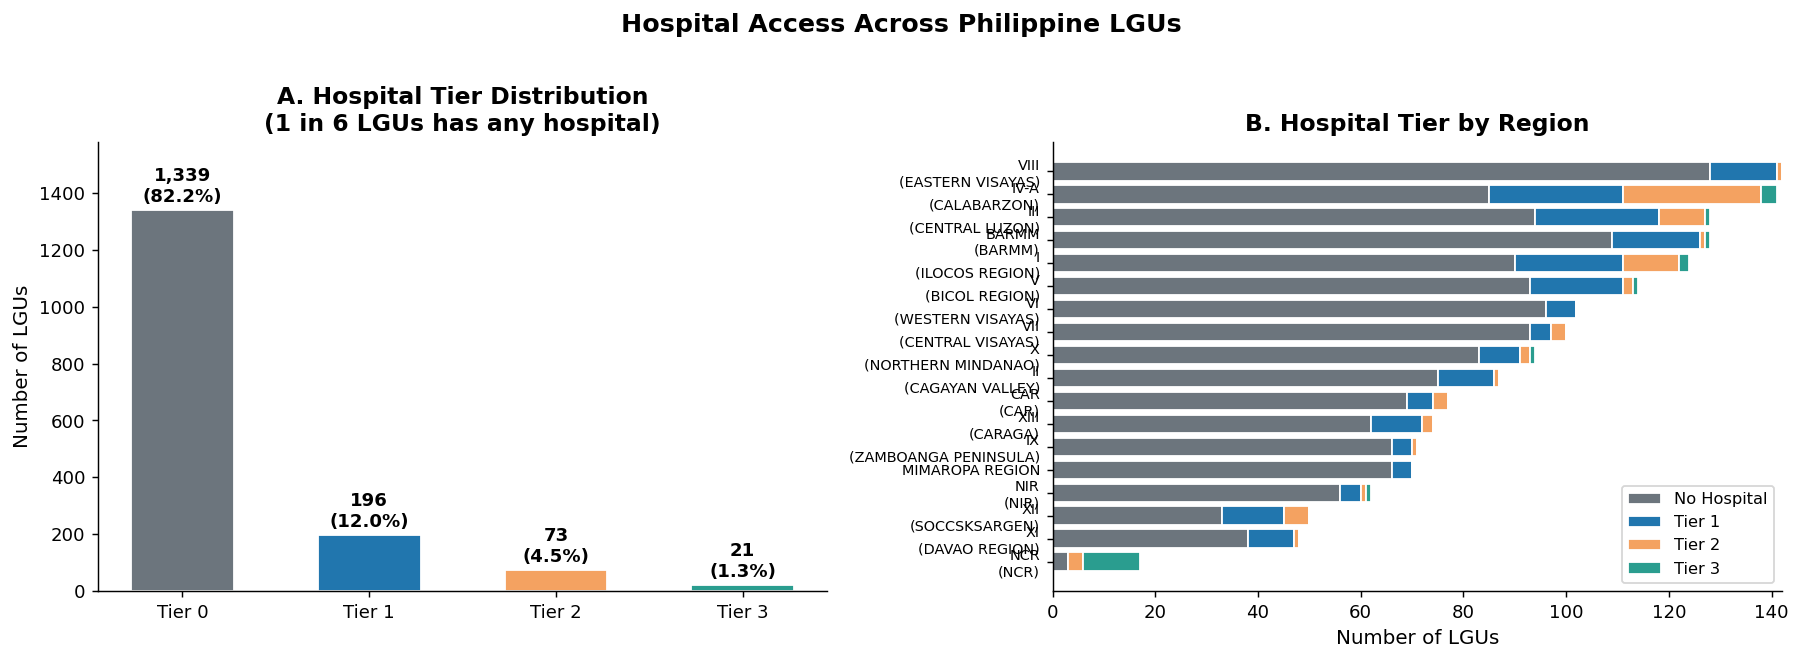

Saved: fig01_tier_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: tier distribution
counts = model_df['tier'].value_counts().sort_index()
bars   = axes[0].bar(TIER_SHORT, counts.values, color=TIER_COLORS, edgecolor='white', width=0.55)
for bar, cnt in zip(bars, counts.values):
    pct = cnt / len(model_df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15,
                 f'{cnt:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Number of LGUs')
axes[0].set_title('A. Hospital Tier Distribution\n(1 in 6 LGUs has any hospital)')
axes[0].set_ylim(0, counts.max() * 1.18)

# Panel B: hospitals by region (stacked bar sorted by total)
region_tier = model_df.groupby(['region','tier']).size().unstack(fill_value=0)
region_tier.columns = [f'Tier {c}' for c in region_tier.columns]
# Shorten region names for readability
def shorten(r):
    r = r.replace('BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANAO','BARMM')
    r = r.replace('CORDILLERA ADMINISTRATIVE REGION','CAR')
    r = r.replace('NATIONAL CAPITAL REGION','NCR')
    r = r.replace('NEGROS ISLAND REGION','NIR')
    r = (r.replace('REGION ','').replace(' (','\n(')
          .replace(') ',')')
          .replace('CARAGA','CARAGA'))
    return r.strip()
region_tier.index = [shorten(r) for r in region_tier.index]
region_total = region_tier.sum(axis=1).sort_values(ascending=True)
region_tier  = region_tier.loc[region_total.index]

bottom = np.zeros(len(region_tier))
for col, color in zip(region_tier.columns, TIER_COLORS):
    axes[1].barh(region_tier.index, region_tier[col], left=bottom,
                 color=color, edgecolor='white', label=col.replace('Tier 0','No Hospital'))
    bottom += region_tier[col].values

axes[1].set_xlabel('Number of LGUs')
axes[1].set_title('B. Hospital Tier by Region')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Hospital Access Across Philippine LGUs',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig01_tier_distribution.png')


---
## Figure 2 — Poverty and Population by Hospital Tier

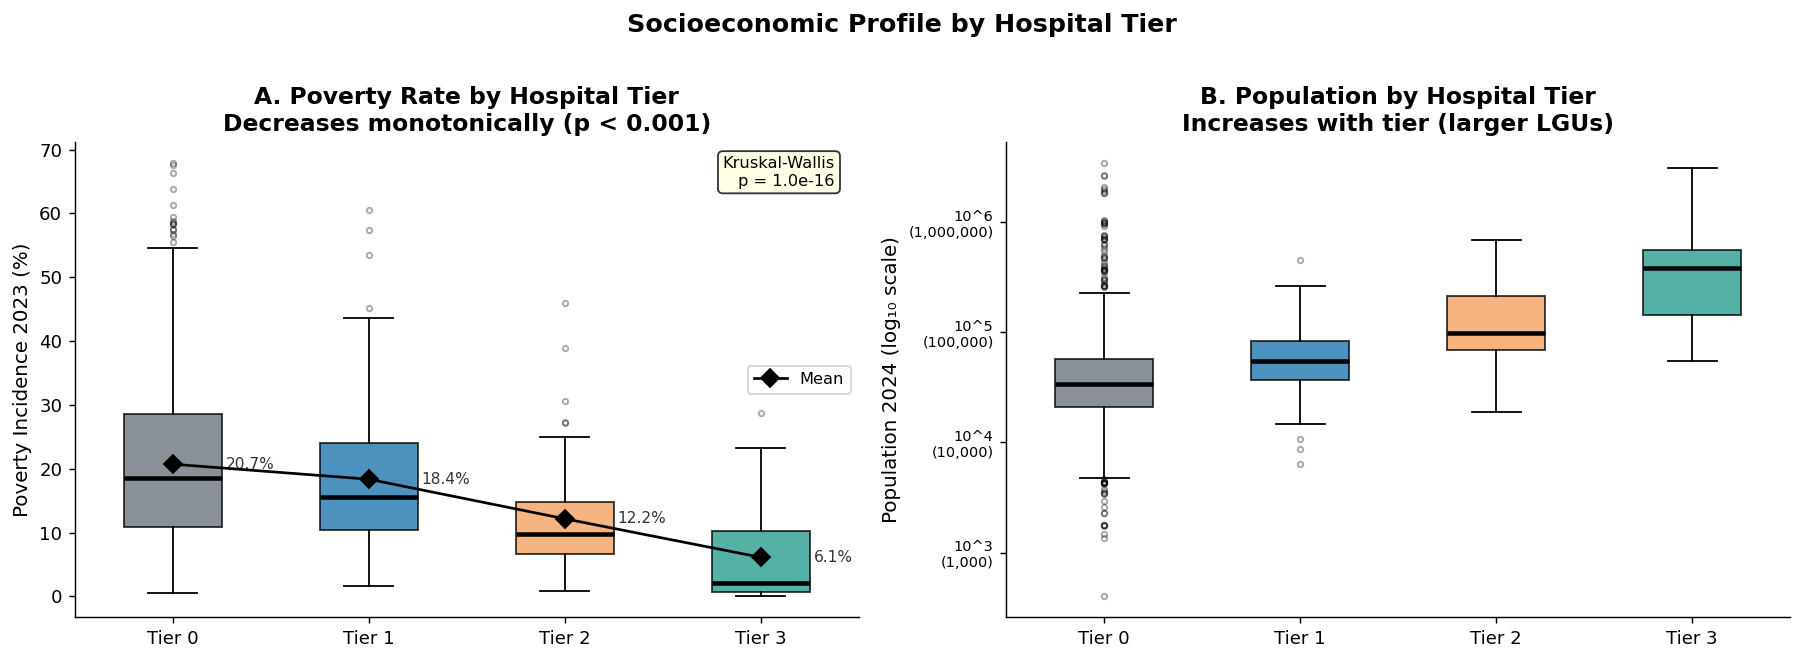

Saved: fig02_poverty_population_by_tier.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pov_data = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].dropna().values for t in range(4)]
pop_data = [np.log10(model_df[model_df['tier']==t]['population_2024'].dropna().clip(lower=1)) for t in range(4)]

# Panel A: Poverty boxplot
bp = axes[0].boxplot(pov_data, labels=TIER_SHORT, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.35, color='grey'))
for patch, c in zip(bp['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.8)
means = [v.mean() for v in pov_data]
axes[0].plot(range(1,5), means, 'D-', color='black', ms=7, zorder=5, label='Mean')
for i, (mn, med) in enumerate(zip(means, [np.median(v) for v in pov_data]), 1):
    axes[0].text(i + 0.27, mn, f'{mn:.1f}%', va='center', fontsize=8.5, color='#333')
axes[0].set_ylabel('Poverty Incidence 2023 (%)')
axes[0].set_title('A. Poverty Rate by Hospital Tier\nDecreases monotonically (p < 0.001)')
axes[0].legend(fontsize=9)

# Annotate the trend
stat_kw, p_kw = stats.kruskal(*pov_data)
axes[0].text(0.97, 0.97, f'Kruskal-Wallis\np = {p_kw:.1e}',
             ha='right', va='top', transform=axes[0].transAxes,
             fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Panel B: Population boxplot (log scale)
bp2 = axes[1].boxplot(pop_data, labels=TIER_SHORT, patch_artist=True, widths=0.5,
                       medianprops=dict(color='black', linewidth=2.5),
                       flierprops=dict(marker='o', markersize=3, alpha=0.35, color='grey'))
for patch, c in zip(bp2['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.8)
axes[1].set_ylabel('Population 2024 (log₁₀ scale)')
axes[1].set_title('B. Population by Hospital Tier\nIncreases with tier (larger LGUs)')
yticks = [3, 4, 5, 6]
axes[1].set_yticks(yticks)
axes[1].set_yticklabels([f'10^{y:d}\n({10**y:,})' for y in yticks], fontsize=8)

plt.suptitle('Socioeconomic Profile by Hospital Tier',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig02_poverty_population_by_tier.png')


---
## Figure 3 — PCA: From 9 Features to 4 Interpretable Components

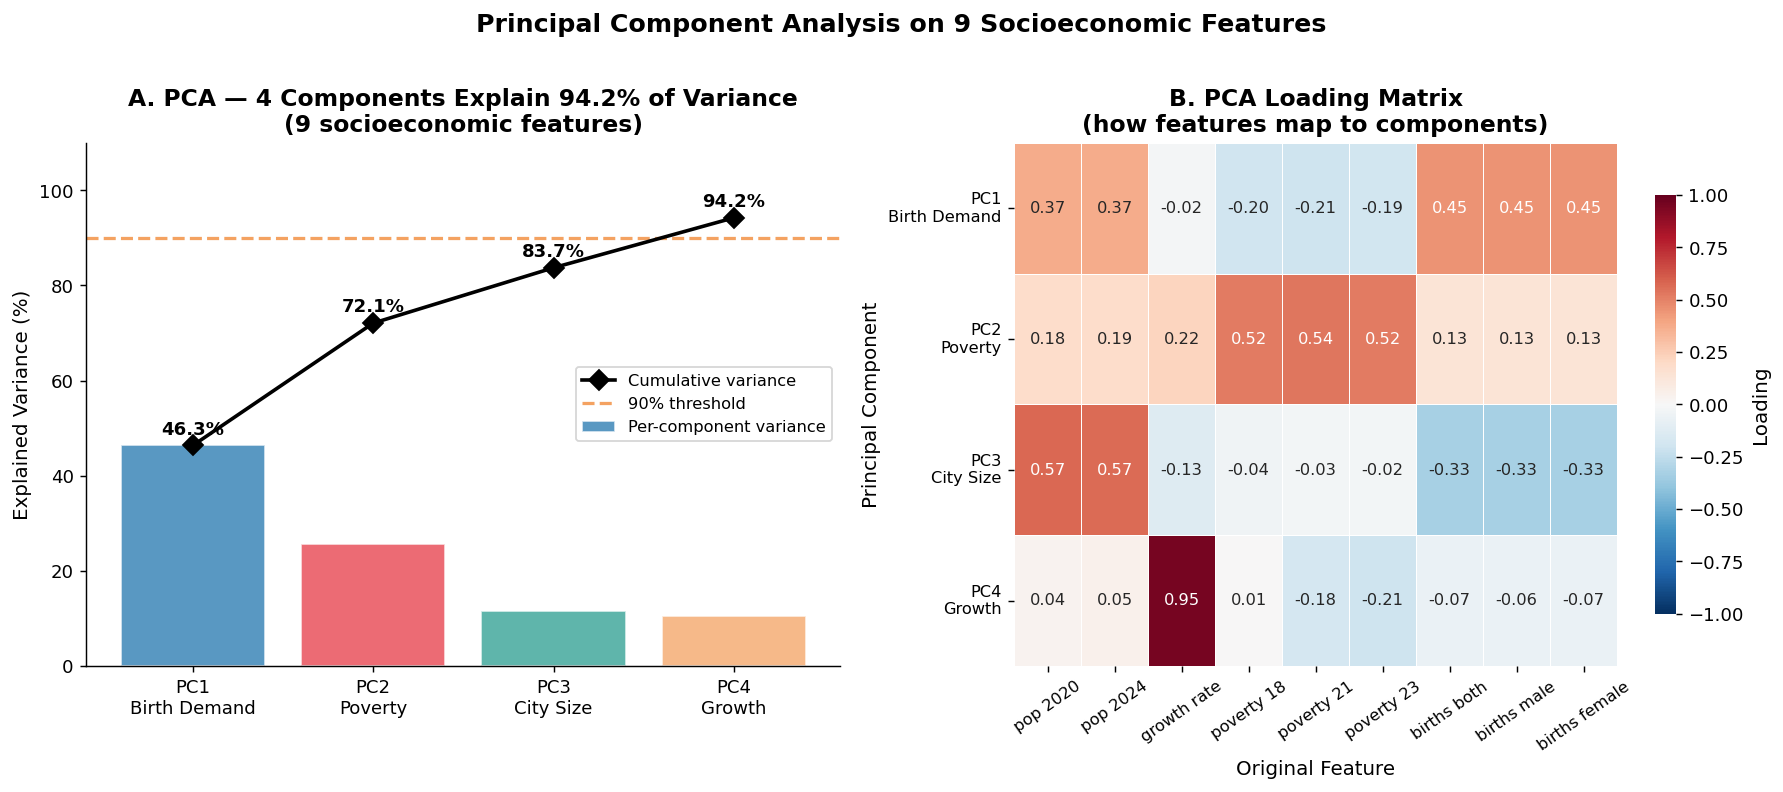

Saved: fig03_pca_components.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: cumulative explained variance
evr    = pca.explained_variance_ratio_
cum_ev = evr.cumsum()
x_pos  = np.arange(1, 5)

axes[0].bar(x_pos, evr * 100, color=PC_COLORS, edgecolor='white', alpha=0.75,
            label='Per-component variance')
axes[0].plot(x_pos, cum_ev * 100, 'D-', color='black', ms=8, lw=2,
             label='Cumulative variance', zorder=5)
for xi, (ev, cv) in enumerate(zip(evr, cum_ev), 1):
    axes[0].text(xi, cv * 100 + 1.5, f'{cv*100:.1f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(90, color=ORANGE, linestyle='--', lw=1.8, label='90% threshold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['PC1\nBirth Demand', 'PC2\nPoverty',
                          'PC3\nCity Size', 'PC4\nGrowth'], fontsize=10)
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_ylim(0, 110)
axes[0].set_title('A. PCA — 4 Components Explain 94.2% of Variance\n(9 socioeconomic features)')
axes[0].legend(fontsize=9, loc='center right')

# Panel B: loading heatmap
W = pd.DataFrame(pca.components_, index=['PC1\nBirth Demand','PC2\nPoverty',
                                          'PC3\nCity Size','PC4\nGrowth'],
                  columns=['pop 2020','pop 2024','growth rate',
                            'poverty 18','poverty 21','poverty 23',
                            'births both','births male','births female'])
sns.heatmap(W, ax=axes[1], annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, cbar_kws={'label': 'Loading', 'shrink': 0.8})
axes[1].set_title('B. PCA Loading Matrix\n(how features map to components)')
axes[1].set_xlabel('Original Feature')
axes[1].set_ylabel('Principal Component')
axes[1].tick_params(axis='x', rotation=35, labelsize=9)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('Principal Component Analysis on 9 Socioeconomic Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig03_pca_components.png')


---
## Figure 4 — PCA Biplot: LGU Scores in Component Space

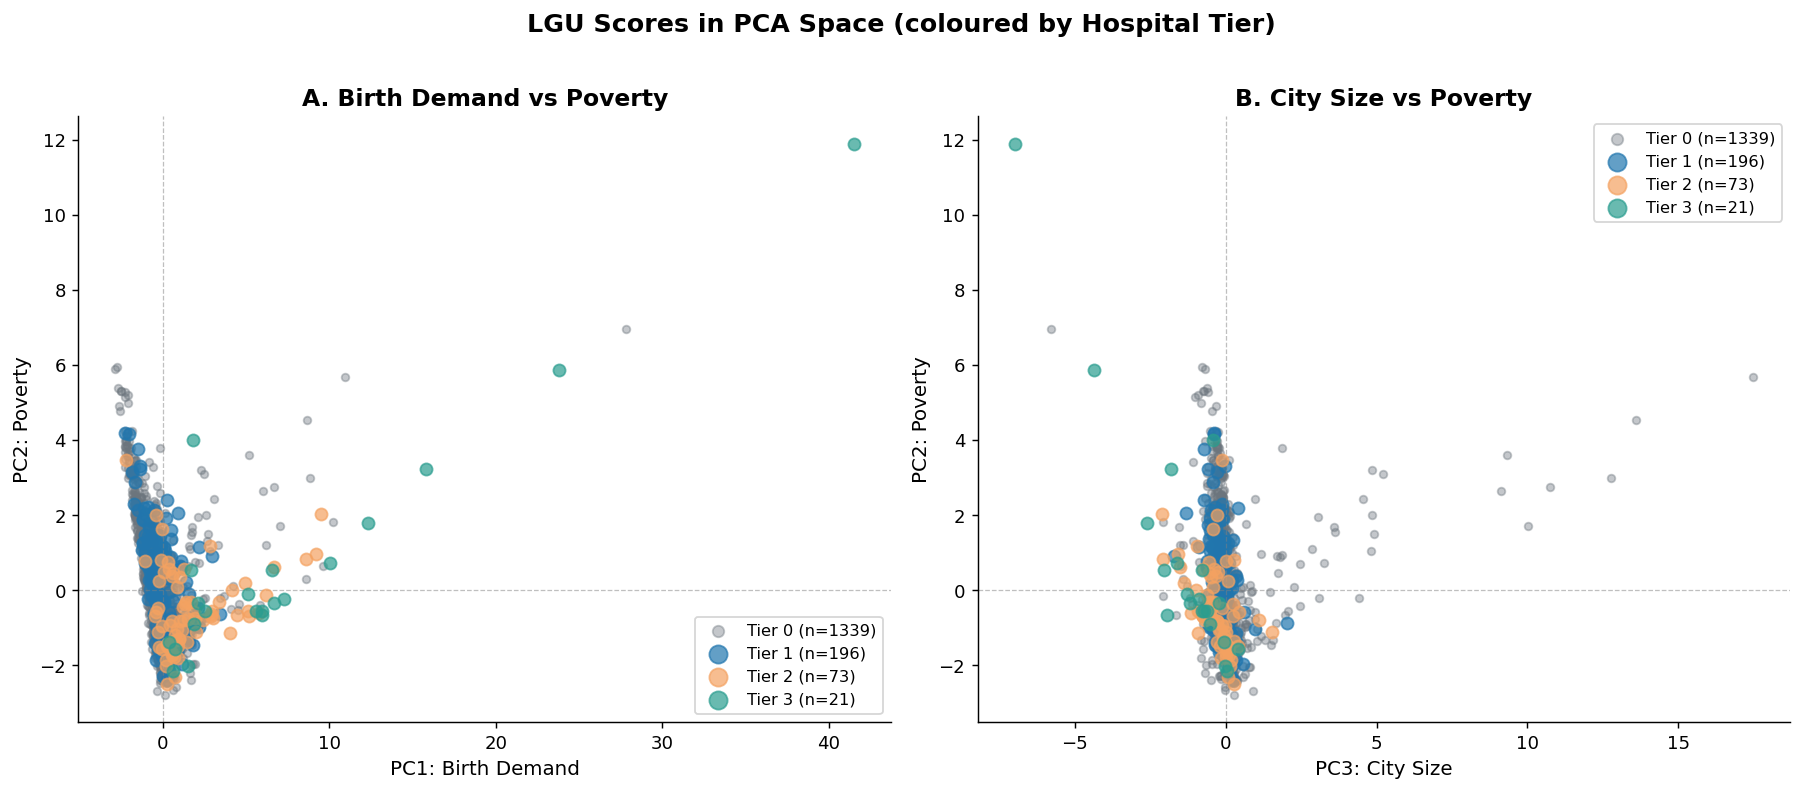

Saved: fig04_pca_biplot.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pc_scores = X_all_pca
tier_vals  = y_all.values

for ax, (pc_x, pc_y, xlab, ylab, title) in zip(axes, [
    (0, 1, 'PC1: Birth Demand', 'PC2: Poverty', 'A. Birth Demand vs Poverty'),
    (2, 1, 'PC3: City Size',    'PC2: Poverty', 'B. City Size vs Poverty'),
]):
    for t in [0, 1, 2, 3]:
        mask = tier_vals == t
        ax.scatter(pc_scores[mask, pc_x], pc_scores[mask, pc_y],
                   color=TIER_COLORS[t], alpha=0.4 if t == 0 else 0.7,
                   s=18 if t == 0 else 45, zorder=t + 1,
                   label=f'Tier {t} (n={mask.sum()})')
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.axhline(0, color='grey', lw=0.7, linestyle='--', alpha=0.5)
    ax.axvline(0, color='grey', lw=0.7, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9, markerscale=1.5)

plt.suptitle('LGU Scores in PCA Space (coloured by Hospital Tier)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig04_pca_biplot.png')


---
## Figure 5 — Model Performance: All Five Models

In [7]:
# Run the 20-seed sweep to get proper mean ± std for each model
# (concise version — just the sweep values needed for the bar chart)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

No_trials = 20
C_settings = [1e-5,1e-3,0.1,0.2,0.4,0.75,1,1.5,3,5,10,15,20,100,300,1000,10000]

def best_accuracy(model_fn, X_source, y_source, param_list, param_key):
    all_te = pd.DataFrame()
    for seedN in range(1, No_trials + 1):
        Xtr,Xte,ytr,yte = train_test_split(X_source, y_source, test_size=0.25,
                                             random_state=seedN, stratify=y_source)
        accs = []
        for p in param_list:
            m = model_fn(p); m.fit(Xtr, ytr); accs.append(m.score(Xte, yte))
        all_te[seedN] = accs
    best_idx = all_te.mean(axis=1).idxmax()
    return all_te.mean(axis=1).max(), all_te.std(axis=1).iloc[best_idx], param_list[best_idx]

print("Running sweeps for comparison chart...")
knn_mu,knn_sd,bk = best_accuracy(lambda k: KNeighborsClassifier(n_neighbors=k),
                                   X_all_pca, y_all, list(range(1,41)), 'k')
print(f"  kNN done: best k={bk}, acc={knn_mu:.4f}")

lr2_mu,lr2_sd,bC2 = best_accuracy(
    lambda C: LogisticRegression(C=C,class_weight='balanced',solver='lbfgs',max_iter=1000,random_state=42),
    X_all_pca, y_all, C_settings, 'C')
print(f"  L2 done: best C={bC2}, acc={lr2_mu:.4f}")

lr1_mu,lr1_sd,bC1 = best_accuracy(
    lambda C: OneVsRestClassifier(LogisticRegression(C=C,penalty='l1',solver='liblinear',max_iter=1000,class_weight='balanced')),
    X_all_pca, y_all, C_settings, 'C')
print(f"  L1 done: best C={bC1}, acc={lr1_mu:.4f}")

rf_mu,rf_sd,bd_rf = best_accuracy(
    lambda d: RandomForestClassifier(n_estimators=100,max_depth=d,class_weight='balanced',random_state=0,n_jobs=-1),
    X_all_pca, y_all, list(range(1,21)), 'depth')
print(f"  RF done: best depth={bd_rf}, acc={rf_mu:.4f}")

gbm_mu,gbm_sd,bd_gbm = best_accuracy(
    lambda d: GradientBoostingClassifier(n_estimators=100,max_depth=d,learning_rate=0.1,random_state=0),
    X_all_pca, y_all, list(range(1,6)), 'depth')
print(f"  GBM done: best depth={bd_gbm}, acc={gbm_mu:.4f}")


Running sweeps for comparison chart...
  kNN done: best k=31, acc=0.8232
  L2 done: best C=1e-05, acc=0.7877
  L1 done: best C=10, acc=0.6398
  RF done: best depth=19, acc=0.8183
  GBM done: best depth=1, acc=0.8234


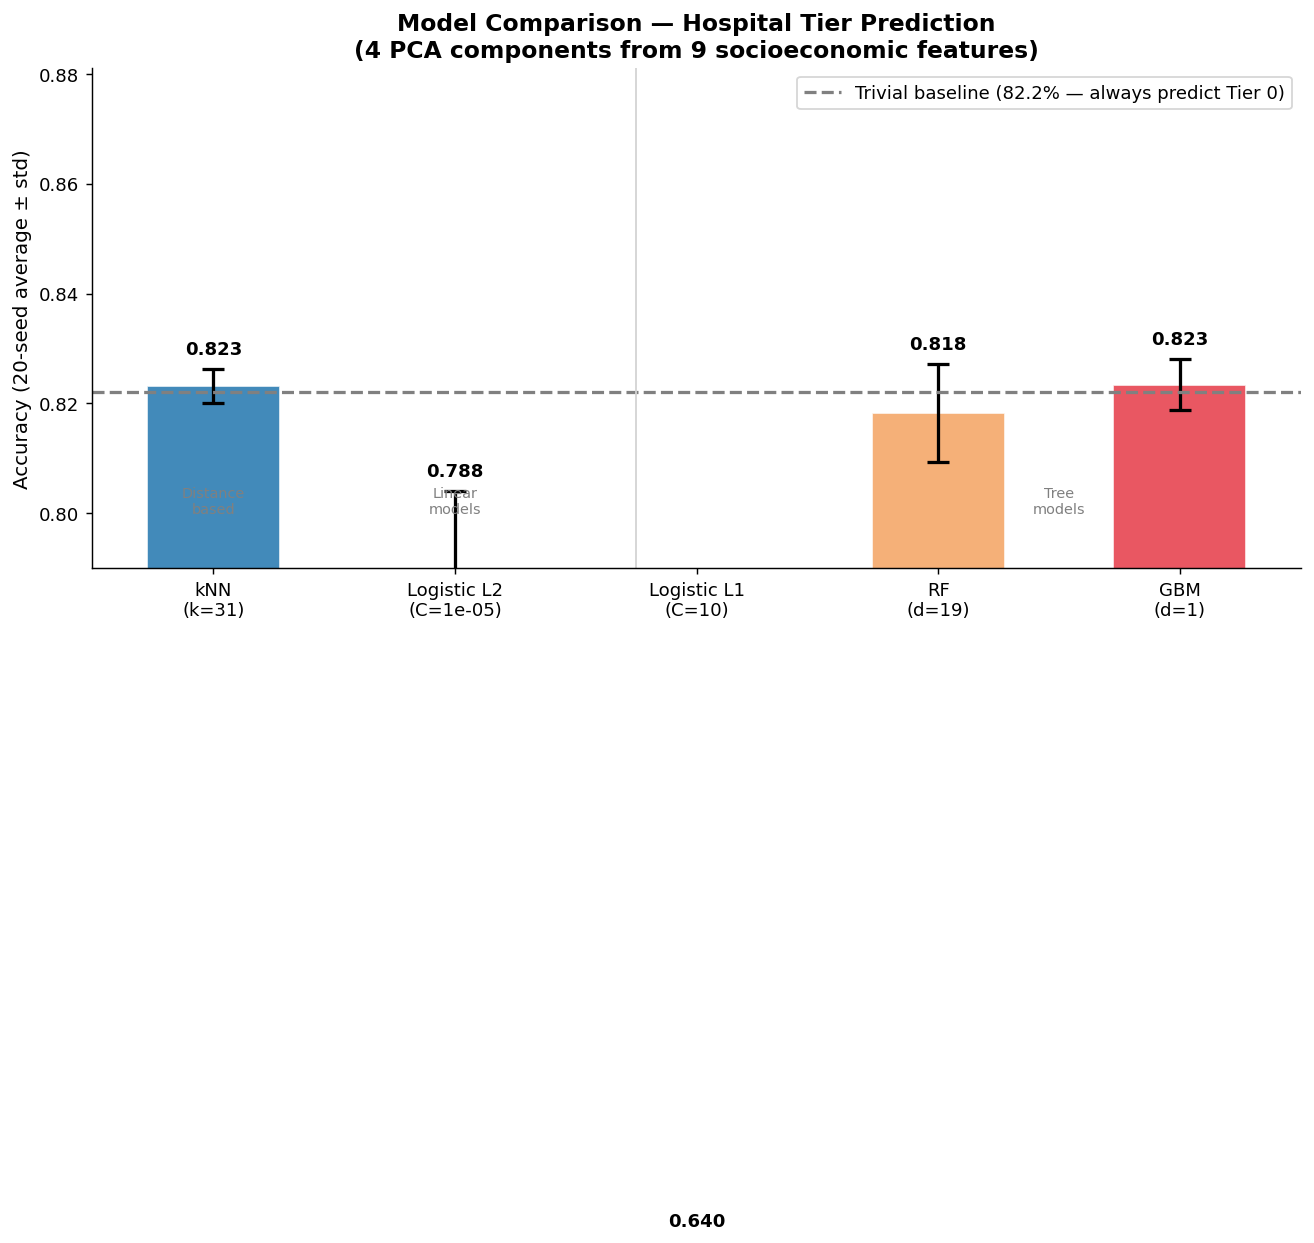

Saved: fig05_model_comparison.png


In [8]:
model_labels = [f'kNN\n(k={bk})', f'Logistic L2\n(C={bC2})',
                f'Logistic L1\n(C={bC1})', f'RF\n(d={bd_rf})', f'GBM\n(d={bd_gbm})']
sweep_means  = [knn_mu, lr2_mu, lr1_mu, rf_mu, gbm_mu]
sweep_stds   = [knn_sd, lr2_sd, lr1_sd, rf_sd, gbm_sd]
bar_colors   = [BLUE, GREEN, GREEN, ORANGE, RED]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(model_labels))
bars = ax.bar(x, sweep_means, color=bar_colors, edgecolor='white', width=0.55, alpha=0.85)
ax.errorbar(x, sweep_means, yerr=sweep_stds, fmt='none', color='black',
            capsize=6, capthick=1.8, elinewidth=1.8)

for xi, (mn, sd) in enumerate(zip(sweep_means, sweep_stds)):
    ax.text(xi, mn + sd + 0.002, f'{mn:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0.822, color='grey', linestyle='--', lw=1.8, label='Trivial baseline (82.2% — always predict Tier 0)')
ax.set_xticks(x); ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel('Accuracy (20-seed average ± std)')
ax.set_ylim(0.79, min(1.0, max(sweep_means) + max(sweep_stds) + 0.03))
ax.set_title('Model Comparison — Hospital Tier Prediction\n(4 PCA components from 9 socioeconomic features)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Add model family annotations
ax.annotate('Distance\nbased', xy=(0, 0.80), ha='center', fontsize=8, color='grey')
ax.annotate('Linear\nmodels', xy=(1, 0.80), ha='center', fontsize=8, color='grey')
ax.annotate('Tree\nmodels', xy=(3.5, 0.80), ha='center', fontsize=8, color='grey')
ax.axvline(1.75, color='lightgrey', lw=1, linestyle='-')

plt.tight_layout()
savefig('fig05_model_comparison.png')


---
## Figure 6 — Feature Importance: Which PC Drives Tier Prediction?

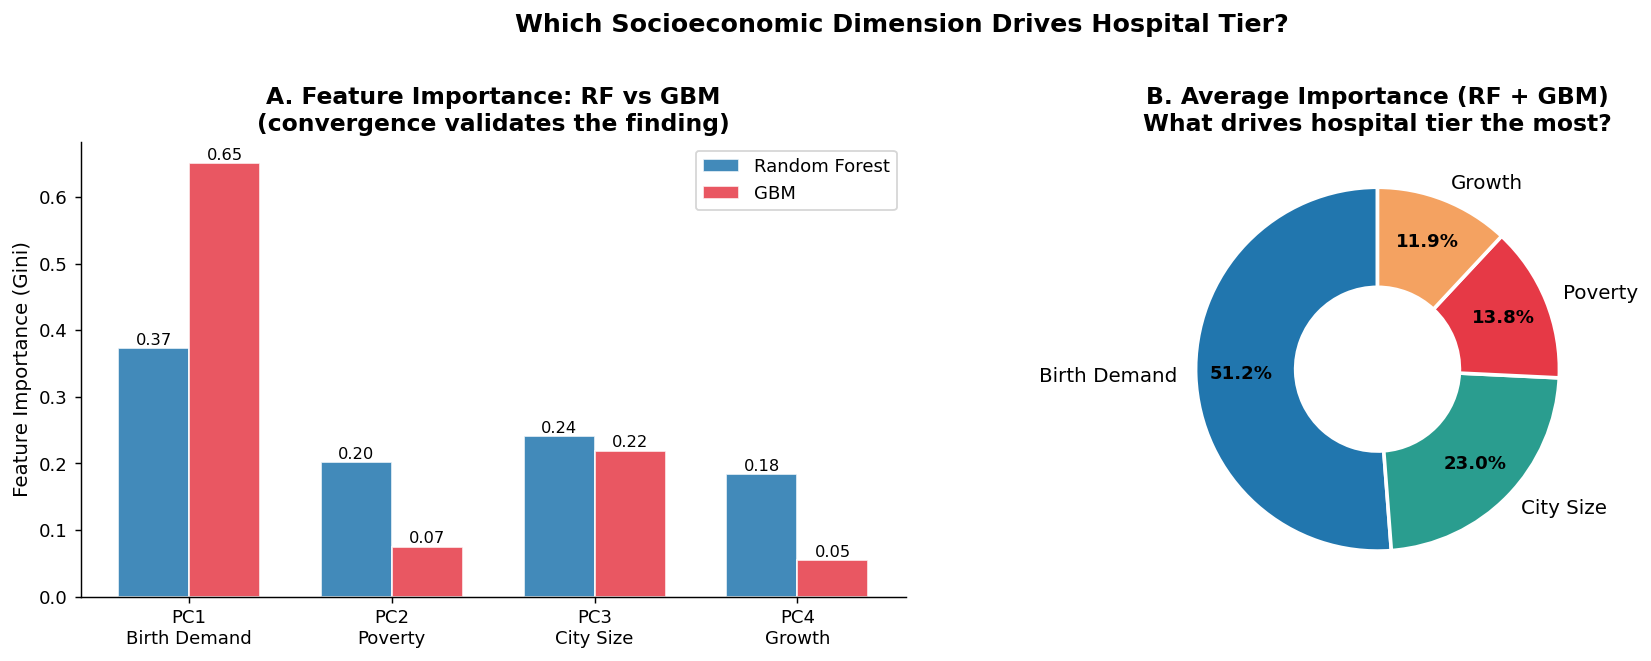

Saved: fig06_feature_importance.png


In [9]:
# Fit final models for feature importance
rf_final  = RandomForestClassifier(n_estimators=300, max_depth=int(bd_rf),
                                    class_weight='balanced', random_state=0, n_jobs=-1)
rf_final.fit(X_tr_pca, y_tr)
gbm_final = GradientBoostingClassifier(n_estimators=200, max_depth=int(bd_gbm),
                                        learning_rate=0.1, random_state=0)
gbm_final.fit(X_tr_pca, y_tr)

fi_rf  = rf_final.feature_importances_
fi_gbm = gbm_final.feature_importances_
fi_mean = (fi_rf + fi_gbm) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: RF vs GBM side-by-side
xi = np.arange(4)
w  = 0.35
axes[0].bar(xi - w/2, fi_rf,  w, color=BLUE,   edgecolor='white', label='Random Forest', alpha=0.85)
axes[0].bar(xi + w/2, fi_gbm, w, color=RED,    edgecolor='white', label='GBM',           alpha=0.85)
axes[0].set_xticks(xi)
axes[0].set_xticklabels(['PC1\nBirth Demand', 'PC2\nPoverty', 'PC3\nCity Size', 'PC4\nGrowth'],
                         fontsize=10)
axes[0].set_ylabel('Feature Importance (Gini)')
axes[0].set_title('A. Feature Importance: RF vs GBM\n(convergence validates the finding)')
axes[0].legend(fontsize=10)
for xi_i, (rf_v, gbm_v) in enumerate(zip(fi_rf, fi_gbm)):
    axes[0].text(xi_i - w/2, rf_v + 0.005, f'{rf_v:.2f}', ha='center', fontsize=9)
    axes[0].text(xi_i + w/2, gbm_v + 0.005, f'{gbm_v:.2f}', ha='center', fontsize=9)

# Panel B: Average importance as donut
avg_sorted_idx = fi_mean.argsort()[::-1]
labels_sorted  = [['Birth Demand','Poverty','City Size','Growth'][i] for i in avg_sorted_idx]
colors_sorted  = [PC_COLORS[i] for i in avg_sorted_idx]
wedges, texts, autotexts = axes[1].pie(
    fi_mean[avg_sorted_idx], labels=labels_sorted, colors=colors_sorted,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for t in texts: t.set_fontsize(11)
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
axes[1].set_title('B. Average Importance (RF + GBM)\nWhat drives hospital tier the most?')

plt.suptitle('Which Socioeconomic Dimension Drives Hospital Tier?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig06_feature_importance.png')


---
## Figure 7 — The Equity Finding: Poverty Suppresses Tier

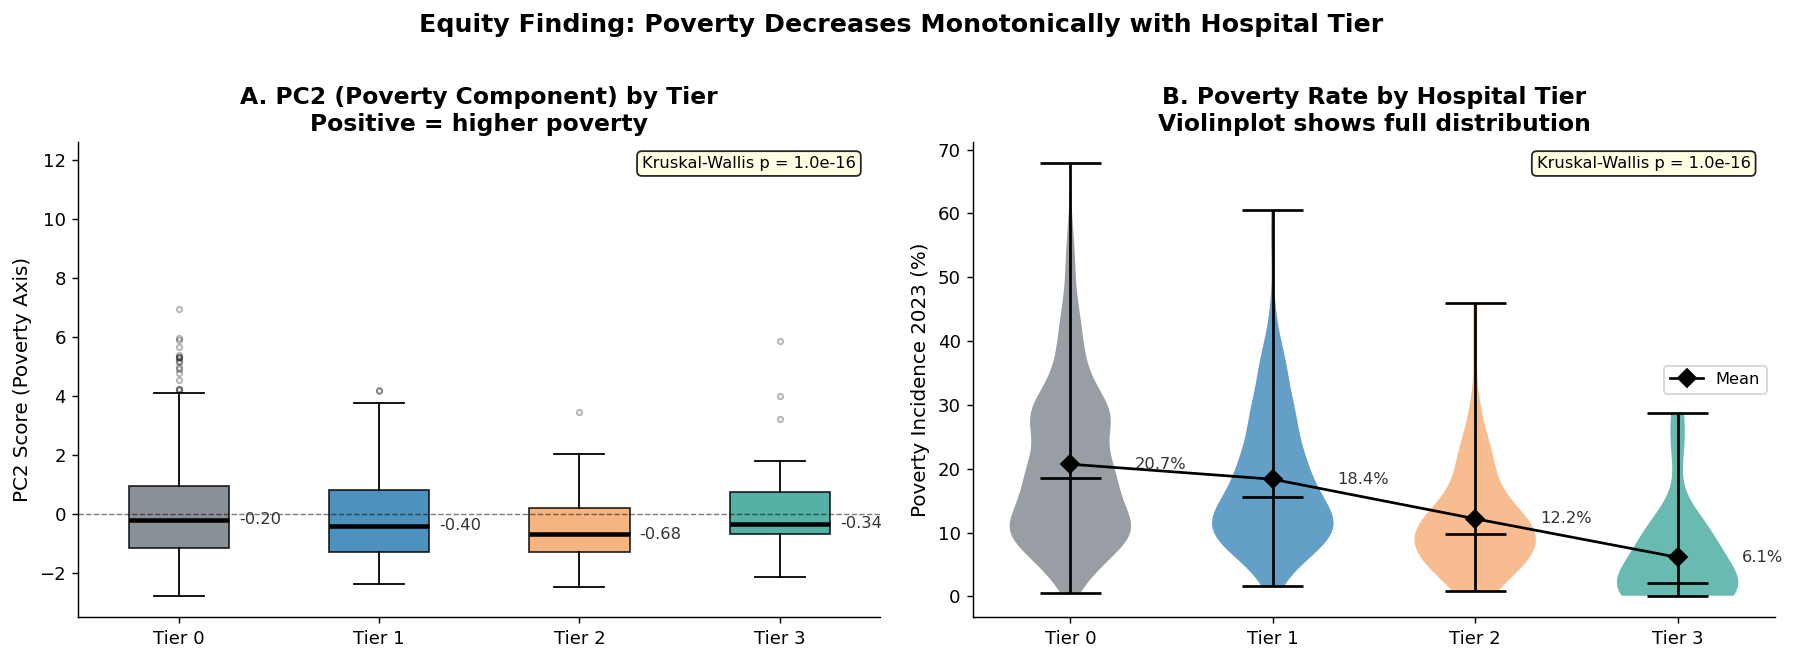

Saved: fig07_equity_poverty_by_tier.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: PC2 (Poverty axis) score by tier — model's internal view
pc2_by_tier = [X_all_pca[(y_all == t).values, 1] for t in range(4)]
bp = axes[0].boxplot(pc2_by_tier, labels=TIER_SHORT, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.3, color='grey'))
for patch, c in zip(bp['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.8)
axes[0].axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
axes[0].set_ylabel('PC2 Score (Poverty Axis)')
axes[0].set_title('A. PC2 (Poverty Component) by Tier\nPositive = higher poverty')
# Add median labels
for i, vals in enumerate(pc2_by_tier, 1):
    axes[0].text(i + 0.3, np.median(vals), f'{np.median(vals):+.2f}',
                 va='center', fontsize=9, color='#333')

# Panel B: Raw poverty incidence by tier with stat annotation
pov_raw = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].dropna().values for t in range(4)]
vp = axes[1].violinplot(pov_raw, positions=range(1,5), showmedians=True, widths=0.6)
for body, c in zip(vp['bodies'], TIER_COLORS):
    body.set_facecolor(c); body.set_alpha(0.7)
for part in ['cmedians','cbars','cmaxes','cmins']:
    vp[part].set_edgecolor('black'); vp[part].set_linewidth(1.5)
means_pov = [v.mean() for v in pov_raw]
axes[1].plot(range(1,5), means_pov, 'D-', color='black', ms=7, zorder=5, label='Mean')
for i, mn in enumerate(means_pov, 1):
    axes[1].text(i + 0.32, mn, f'{mn:.1f}%', va='center', fontsize=9, color='#333')
axes[1].set_xticks(range(1,5)); axes[1].set_xticklabels(TIER_SHORT)
axes[1].set_ylabel('Poverty Incidence 2023 (%)')
axes[1].set_title('B. Poverty Rate by Hospital Tier\nViolinplot shows full distribution')
axes[1].legend(fontsize=9)

stat_kw, p_kw = stats.kruskal(*pov_raw)
for ax in axes:
    ax.text(0.97, 0.97, f'Kruskal-Wallis p = {p_kw:.1e}',
            ha='right', va='top', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85))

plt.suptitle('Equity Finding: Poverty Decreases Monotonically with Hospital Tier',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig07_equity_poverty_by_tier.png')


---
## Figure 8 — Underserved LGU Map: Expected Tier vs Poverty

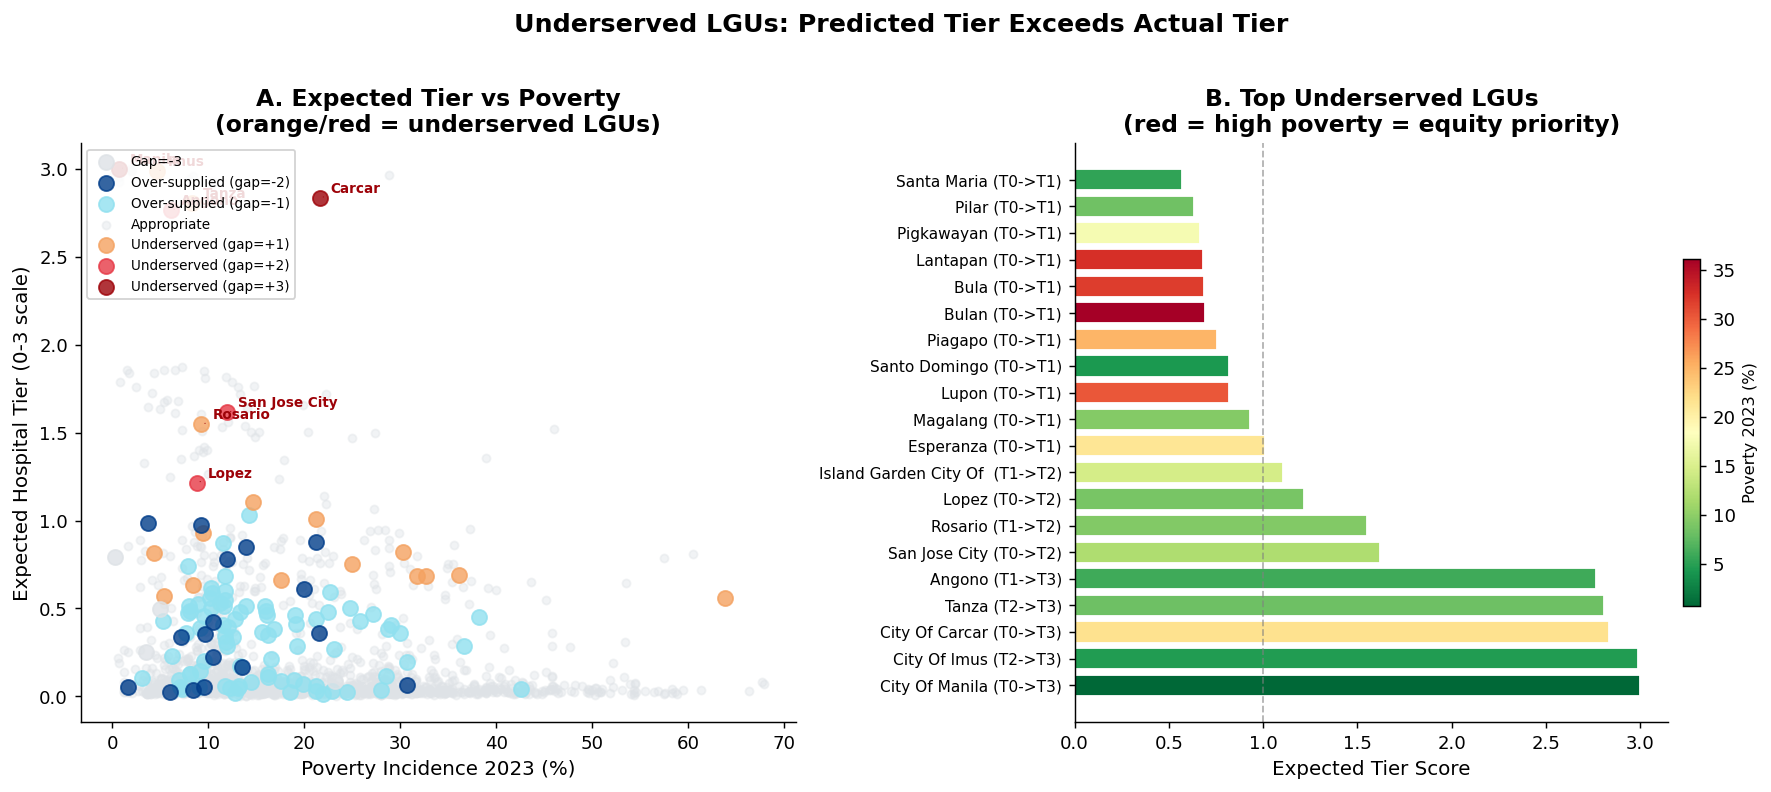

Saved: fig08_underserved_lgu.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: scatter — expected tier vs poverty, colour-coded by tier gap
gap_palette = {-2:'#023e8a', -1:'#90e0ef', 0:'#dee2e6', 1:'#f4a261', 2:'#e63946', 3:'#9d0208'}
gap_labels  = {-2:'Over-supplied (gap=-2)', -1:'Over-supplied (gap=-1)',
                0:'Appropriate', 1:'Underserved (gap=+1)',
                2:'Underserved (gap=+2)', 3:'Underserved (gap=+3)'}

for gap_val, grp in model_df.groupby('tier_gap'):
    axes[0].scatter(grp['poverty_incidence_2023_pct'], grp['expected_tier'],
                    color=gap_palette.get(gap_val, '#dee2e6'),
                    alpha=0.4 if gap_val == 0 else 0.8,
                    s=20 if gap_val == 0 else 70,
                    label=gap_labels.get(gap_val, f'Gap={gap_val}'),
                    zorder=abs(gap_val) + 1)

# Annotate top underserved LGUs
for _, row in underserved.head(8).iterrows():
    axes[0].annotate(
        row['city_municipality'].title().replace('City Of ',''),
        (row['poverty_incidence_2023_pct'], row['expected_tier']),
        fontsize=7.5, xytext=(6, 3), textcoords='offset points',
        color='#9d0208', fontweight='bold',
        arrowprops=dict(arrowstyle='-', color='#9d0208', lw=0.6)
    )

axes[0].set_xlabel('Poverty Incidence 2023 (%)')
axes[0].set_ylabel('Expected Hospital Tier (0-3 scale)')
axes[0].set_title('A. Expected Tier vs Poverty\n(orange/red = underserved LGUs)')
# Put legend outside right to avoid overlap
axes[0].legend(fontsize=7.5, loc='upper left', framealpha=0.85)

# Panel B: underserved LGUs ranked by expected tier
us_plot = underserved[['city_municipality','region','tier','expected_tier',
                         'poverty_incidence_2023_pct']].copy().head(20)
us_plot['lgu_label'] = us_plot.apply(
    lambda r: f"{r['city_municipality'].title()[:22]} (T{r['tier']}→pred T{int(r['pred_tier'] if 'pred_tier' in r else r['tier']+1)})",
    axis=1
)
# Colour by poverty (red = high poverty = equity priority)
norm_pov = (us_plot['poverty_incidence_2023_pct'] - us_plot['poverty_incidence_2023_pct'].min()) /            (us_plot['poverty_incidence_2023_pct'].max() - us_plot['poverty_incidence_2023_pct'].min() + 1e-9)
bar_cols = [plt.cm.RdYlGn_r(p) for p in norm_pov]

# Need pred_tier in us_plot
us_plot2 = underserved.head(20).copy()
us_plot2['lgu_label'] = us_plot2.apply(
    lambda r: f"{r['city_municipality'].title()[:22]} (T{r['tier']}->T{r['pred_tier']})",
    axis=1
)

bars2 = axes[1].barh(range(len(us_plot2)), us_plot2['expected_tier'],
                      color=[plt.cm.RdYlGn_r(p) for p in norm_pov[:len(us_plot2)]],
                      edgecolor='white')
axes[1].set_yticks(range(len(us_plot2)))
axes[1].set_yticklabels(us_plot2['lgu_label'], fontsize=8.5)
axes[1].set_xlabel('Expected Tier Score')
axes[1].set_title('B. Top Underserved LGUs\n(red = high poverty = equity priority)')
axes[1].axvline(1.0, color='grey', lw=1, linestyle='--', alpha=0.6)

# Colourbar for poverty
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r',
     norm=plt.Normalize(us_plot2['poverty_incidence_2023_pct'].min(),
                        us_plot2['poverty_incidence_2023_pct'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[1], shrink=0.6, pad=0.02)
cbar.set_label('Poverty 2023 (%)', fontsize=9)

plt.suptitle('Underserved LGUs: Predicted Tier Exceeds Actual Tier',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig08_underserved_lgu.png')


---
## Figure 9 — Confusion Matrix and Model Diagnostics

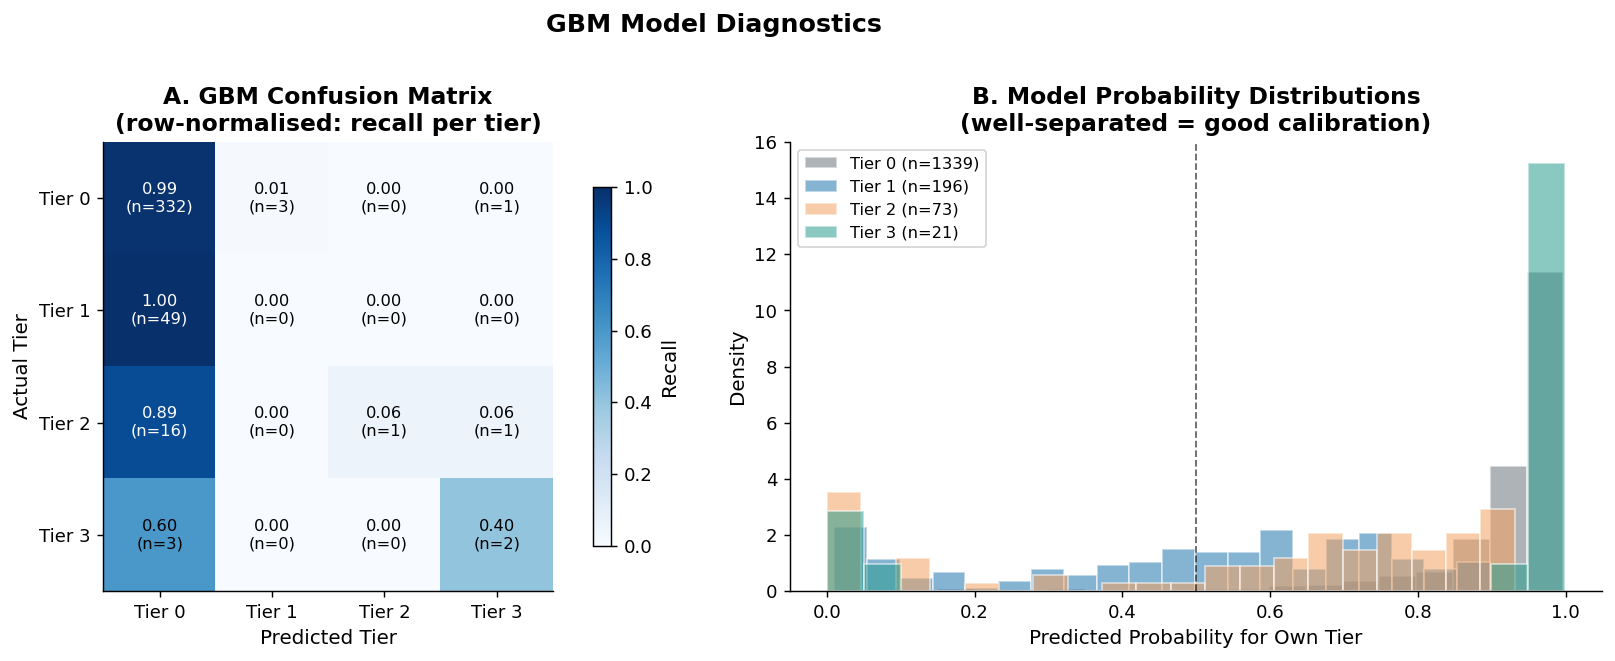

Saved: fig09_model_diagnostics.png


In [12]:
# Re-fit with best params on train, evaluate on test
X_te_pca = pca.transform(scaler.transform(X_te))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: confusion matrix (normalised)
y_pred = gbm_final.predict(X_te_pca)
cm     = confusion_matrix(y_te, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(TIER_SHORT)
axes[0].set_yticks(range(4)); axes[0].set_yticklabels(TIER_SHORT)
axes[0].set_xlabel('Predicted Tier')
axes[0].set_ylabel('Actual Tier')
axes[0].set_title('A. GBM Confusion Matrix\n(row-normalised: recall per tier)')
for i in range(4):
    for j in range(4):
        val = cm_norm[i, j]
        count = cm[i, j]
        axes[0].text(j, i, f'{val:.2f}\n(n={count})',
                     ha='center', va='center', fontsize=9,
                     color='white' if val > 0.6 else 'black')
plt.colorbar(im, ax=axes[0], label='Recall', shrink=0.8)

# Panel B: probability distributions per tier (model calibration)
for t in range(4):
    mask = (y_all == t).values
    probs_for_tier = proba_full[mask, t]
    axes[1].hist(probs_for_tier, bins=20, alpha=0.55, color=TIER_COLORS[t],
                 label=f'Tier {t} (n={mask.sum()})', density=True, edgecolor='white')
axes[1].set_xlabel('Predicted Probability for Own Tier')
axes[1].set_ylabel('Density')
axes[1].set_title('B. Model Probability Distributions\n(well-separated = good calibration)')
axes[1].legend(fontsize=9)
axes[1].axvline(0.5, color='black', lw=1, linestyle='--', alpha=0.6, label='0.5 threshold')

plt.suptitle('GBM Model Diagnostics',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig09_model_diagnostics.png')


---
## Figure 10 — Summary: The Research Story in One Figure

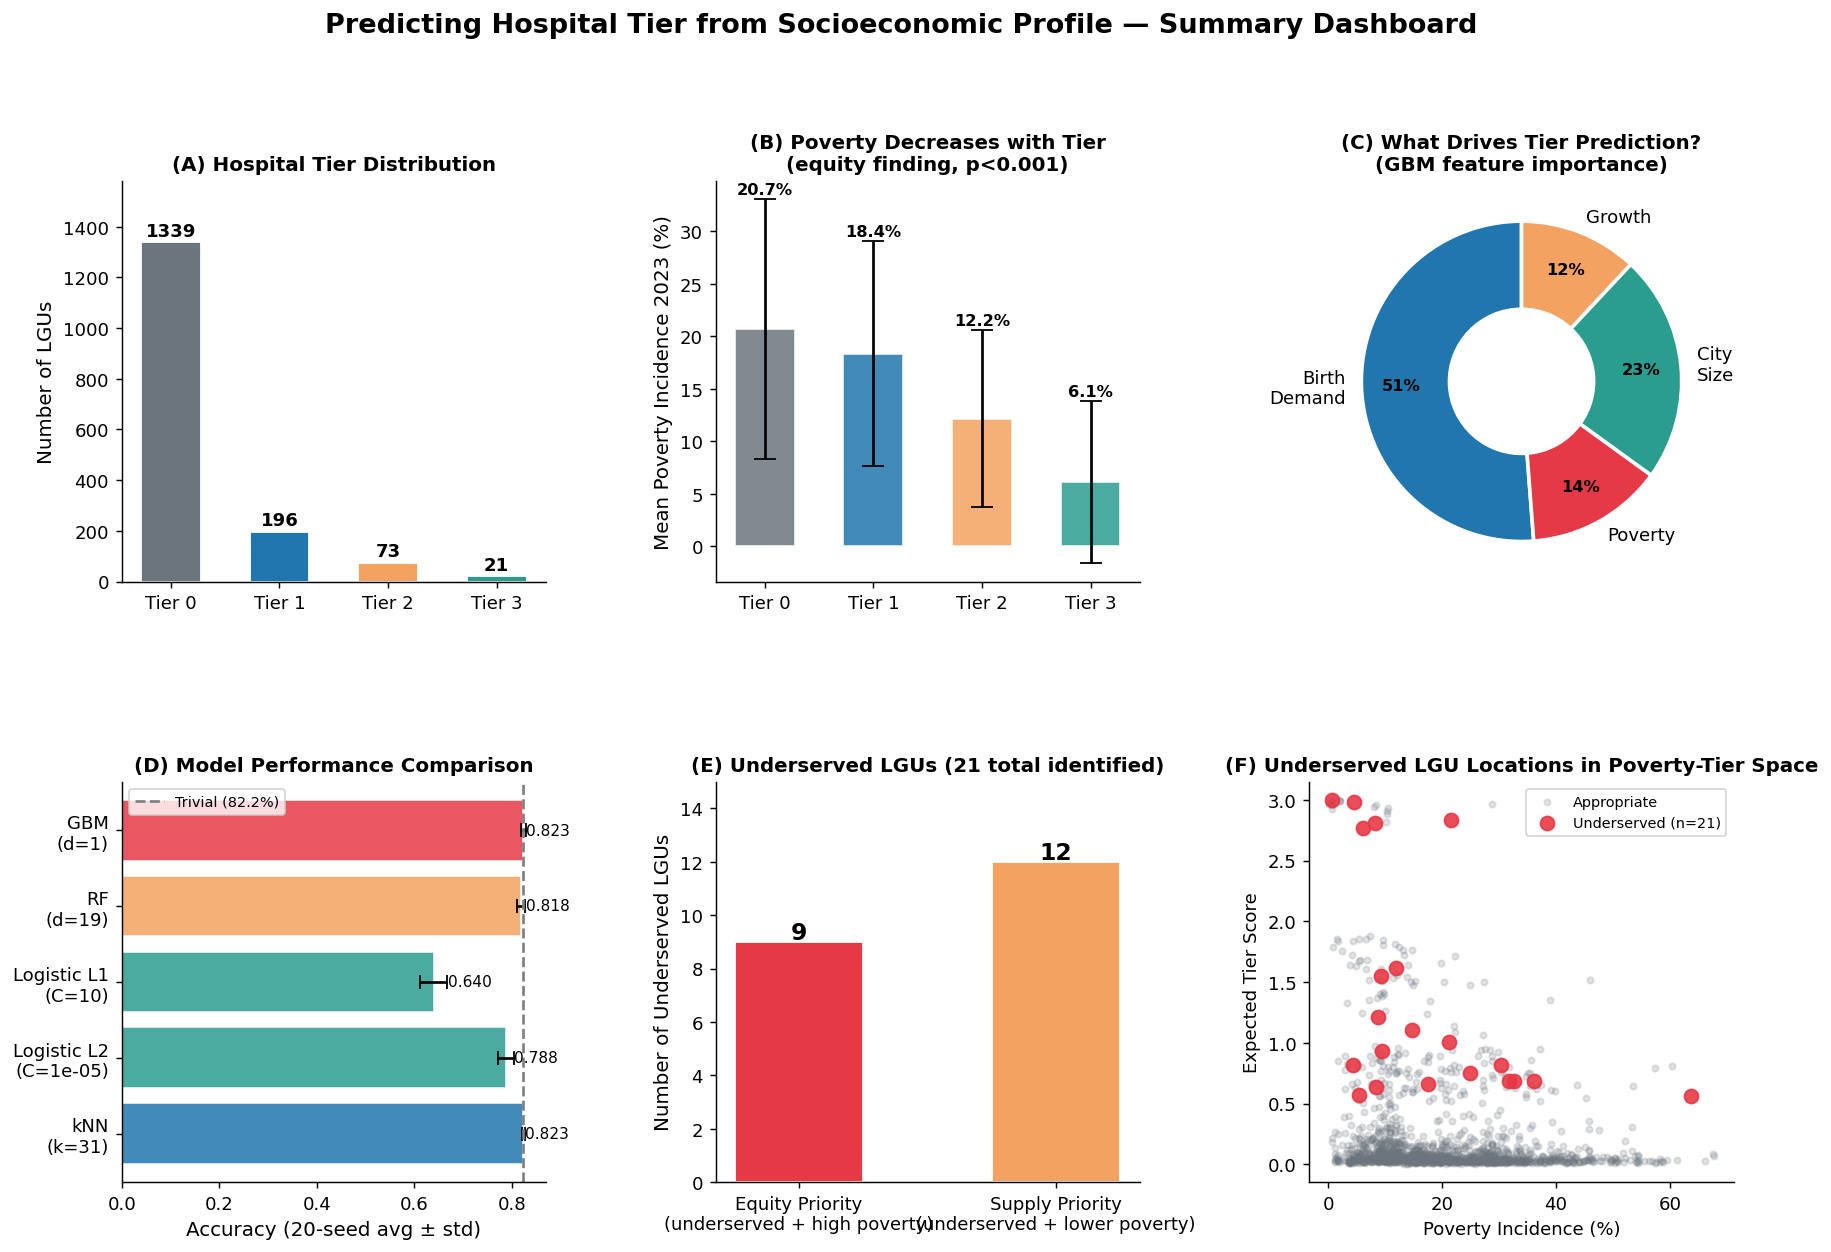

Saved: fig10_summary_dashboard.png


In [13]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

# A: tier distribution
ax_a = fig.add_subplot(gs[0, 0])
counts = model_df['tier'].value_counts().sort_index()
ax_a.bar(TIER_SHORT, counts.values, color=TIER_COLORS, edgecolor='white', width=0.55)
ax_a.set_title('(A) Hospital Tier Distribution', fontweight='bold', fontsize=11)
ax_a.set_ylabel('Number of LGUs')
for i, cnt in enumerate(counts.values):
    ax_a.text(i, cnt + 10, str(cnt), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_a.set_ylim(0, counts.max()*1.18)

# B: poverty by tier (compact)
ax_b = fig.add_subplot(gs[0, 1])
pov_means = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].mean() for t in range(4)]
pov_stds  = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].std()  for t in range(4)]
ax_b.bar(TIER_SHORT, pov_means, yerr=pov_stds, color=TIER_COLORS, edgecolor='white',
          capsize=6, width=0.55, alpha=0.85)
ax_b.set_ylabel('Mean Poverty Incidence 2023 (%)')
ax_b.set_title('(B) Poverty Decreases with Tier\n(equity finding, p<0.001)', fontweight='bold', fontsize=11)
for i, (mn, sd) in enumerate(zip(pov_means, pov_stds)):
    ax_b.text(i, mn + sd + 0.5, f'{mn:.1f}%', ha='center', fontsize=9, fontweight='bold')

# C: feature importance (donut)
ax_c = fig.add_subplot(gs[0, 2])
wedges, _, autotexts = ax_c.pie(
    fi_mean, labels=['Birth\nDemand','Poverty','City\nSize','Growth'],
    colors=PC_COLORS, autopct='%1.0f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(9); at.set_fontweight('bold')
ax_c.set_title('(C) What Drives Tier Prediction?\n(GBM feature importance)', fontweight='bold', fontsize=11)

# D: model comparison (compact)
ax_d = fig.add_subplot(gs[1, 0])
ax_d.barh(model_labels, sweep_means, xerr=sweep_stds, color=bar_colors,
           edgecolor='white', alpha=0.85, capsize=4)
ax_d.axvline(0.822, color='grey', lw=1.5, linestyle='--', label='Trivial (82.2%)')
ax_d.set_xlabel('Accuracy (20-seed avg ± std)')
ax_d.set_title('(D) Model Performance Comparison', fontweight='bold', fontsize=11)
ax_d.legend(fontsize=8)
for i, (mn, sd) in enumerate(zip(sweep_means, sweep_stds)):
    ax_d.text(mn + sd + 0.001, i, f'{mn:.3f}', va='center', fontsize=8.5)

# E: underserved count
ax_e = fig.add_subplot(gs[1, 1])
cat_names = ['Equity Priority\n(underserved + high poverty)', 'Supply Priority\n(underserved + lower poverty)']
cat_counts = [len(eq_prio), len(sup_prio)]
bars_e = ax_e.bar(cat_names, cat_counts, color=[RED, ORANGE], edgecolor='white', width=0.5)
for bar, cnt in zip(bars_e, cat_counts):
    ax_e.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
              str(cnt), ha='center', fontsize=13, fontweight='bold')
ax_e.set_ylabel('Number of Underserved LGUs')
ax_e.set_title(f'(E) Underserved LGUs ({len(underserved)} total identified)', fontweight='bold', fontsize=11)
ax_e.set_ylim(0, max(cat_counts)*1.25)

# F: expected tier scatter (mini version)
ax_f = fig.add_subplot(gs[1, 2])
ax_f.scatter(model_df[model_df['tier_gap']==0]['poverty_incidence_2023_pct'],
             model_df[model_df['tier_gap']==0]['expected_tier'],
             color=GREY, alpha=0.2, s=12, label='Appropriate')
ax_f.scatter(underserved['poverty_incidence_2023_pct'], underserved['expected_tier'],
             color=RED, alpha=0.9, s=60, zorder=5, label=f'Underserved (n={len(underserved)})')
ax_f.set_xlabel('Poverty Incidence (%)', fontsize=10)
ax_f.set_ylabel('Expected Tier Score', fontsize=10)
ax_f.set_title('(F) Underserved LGU Locations in Poverty-Tier Space', fontweight='bold', fontsize=11)
ax_f.legend(fontsize=8)

fig.suptitle('Predicting Hospital Tier from Socioeconomic Profile — Summary Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
savefig('fig10_summary_dashboard.png')


---
## All Figures Saved

In [14]:
import os
figs = sorted([f for f in os.listdir(OUT_DIR) if f.endswith('.png')])
print(f"Saved {len(figs)} figures to '{OUT_DIR}/':")
for f in figs:
    size_kb = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f"  {f:<40} ({size_kb:.0f} KB)")


Saved 10 figures to 'outputs\figures/':
  fig01_tier_distribution.png              (111 KB)
  fig02_poverty_population_by_tier.png     (95 KB)
  fig03_pca_components.png                 (156 KB)
  fig04_pca_biplot.png                     (154 KB)
  fig05_model_comparison.png               (72 KB)
  fig06_feature_importance.png             (100 KB)
  fig07_equity_poverty_by_tier.png         (110 KB)
  fig08_underserved_lgu.png                (233 KB)
  fig09_model_diagnostics.png              (96 KB)
  fig10_summary_dashboard.png              (244 KB)
